In [78]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

spark = SparkSession.builder.appName("EDA Dataset").getOrCreate()

df = spark.read.json(
    "hdfs://localhost:9000/ev-project/data/bronze/ev_sessions/caltech/*/*/*"
)



In [79]:
df.selectExpr(
    "min(connectionTime)",
    "max(connectionTime)"
).show()

[Stage 84:====================================================>   (32 + 2) / 34]

+--------------------+--------------------+
| min(connectionTime)| max(connectionTime)|
+--------------------+--------------------+
|2018-04-25 04:08:...|2021-09-13 18:52:...|
+--------------------+--------------------+



In [80]:
df.count()

31424

In [33]:

df_eda.selectExpr("max(kWhDelivered)", "min(kWhDelivered)").show()

NameError: name 'df_eda' is not defined

In [81]:
pdf = df.orderBy("kWhDelivered").select("kWhDelivered").toPandas()

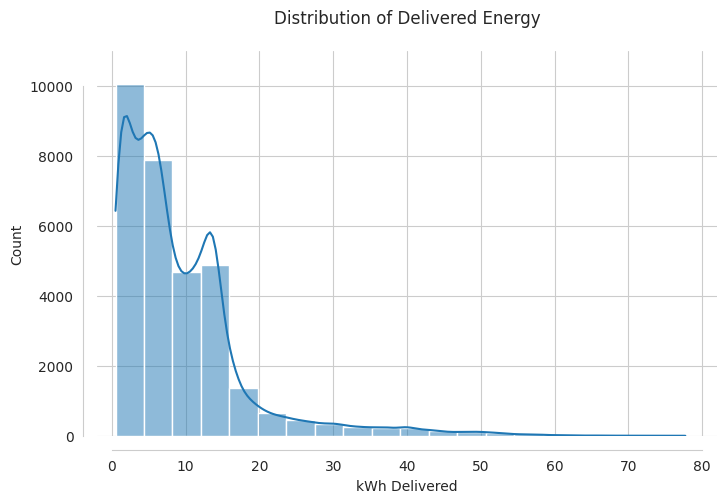

In [82]:
plt.figure(figsize=(8,5))

# Vẽ biểu đồ
sns.histplot(
    pdf["kWhDelivered"],
    bins=20,
    kde=True,
    stat="count",
    edgecolor="white" # Thêm viền trắng để các cột trông tách biệt hơn
)

# 1. Tạo khoảng cách giữa dữ liệu và trục tọa độ
plt.margins(x=0.02) 

# 2. Điều chỉnh giới hạn trục để không bị cụt
plt.xlim(-2, 82)
plt.ylim(0, 11000)

# 3. Làm đẹp theo phong cách Paper
sns.despine(offset=10, trim=True) 

plt.xlabel("kWh Delivered")
plt.ylabel("Count")
plt.title("Distribution of Delivered Energy", pad=20) # Thêm pad để tiêu đề không dính vào hình

plt.show()

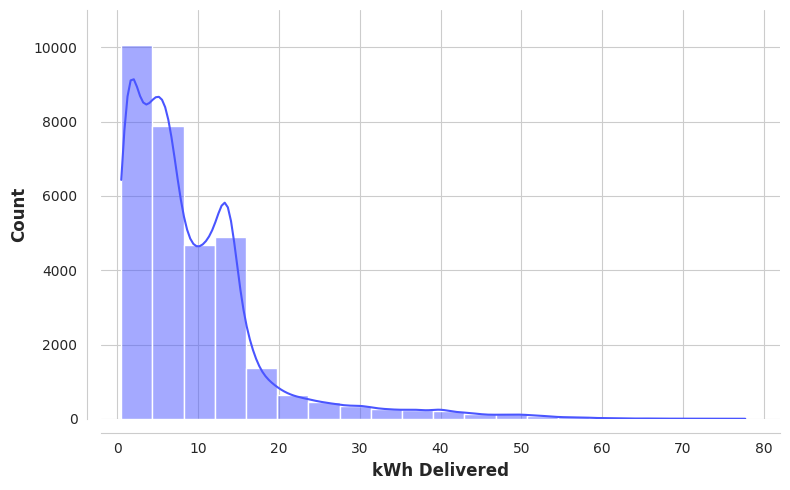

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Thiết lập style trắng có lưới (whitegrid) giống trong paper
sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))

# 2. Vẽ biểu đồ với màu xanh đặc trưng và viền cột trắng
sns.histplot(
    pdf["kWhDelivered"],
    bins=20,
    kde=True,
    stat="count",
    color="#4A55FF",      # Màu xanh giống hình paper
    edgecolor="white",    # Viền trắng giữa các cột
    linewidth=1
)

# 3. Tạo khoảng cách giữa trục và dữ liệu (Quan trọng nhất)
# Dùng despine với offset để đẩy trục ra xa, trim=True để giới hạn trục vừa khớp dữ liệu
sns.despine(offset=10, trim=False, left=False, bottom=False)

# 4. Tinh chỉnh các trục để không bắt đầu sát rạt (0,0)
plt.xlim(-2, 82)
plt.ylim(0, 11000)

# 5. Định dạng nhãn trục (Bold và Size)
plt.xlabel("kWh Delivered", fontweight='bold', fontsize=12)
plt.ylabel("Count", fontweight='bold', fontsize=12)

# Thêm chú thích hình dưới cùng (Caption style)
#plt.figtext(0.5, -0.05, "Fig. 2. Distribution of delivered energy.", 
#            wrap=True, horizontalalignment='center', fontsize=10)

plt.tight_layout()
plt.show()

# Figure 3

In [84]:
# Cast timestamp
df = df.withColumn("connectionTime", to_timestamp("connectionTime")) \
       .withColumn("disconnectTime", to_timestamp("disconnectTime")) \
       .withColumn("doneChargingTime", to_timestamp("doneChargingTime"))


In [85]:
df = df.withColumn(
    "charging_duration",
    (col("doneChargingTime").cast("long") - col("connectionTime").cast("long")) / 3600
)

In [86]:
pdf = df.select("charging_duration", "kWhDelivered").toPandas()

In [87]:
pdf = pdf[(pdf["charging_duration"] > 0) & (pdf["kWhDelivered"] > 0)]

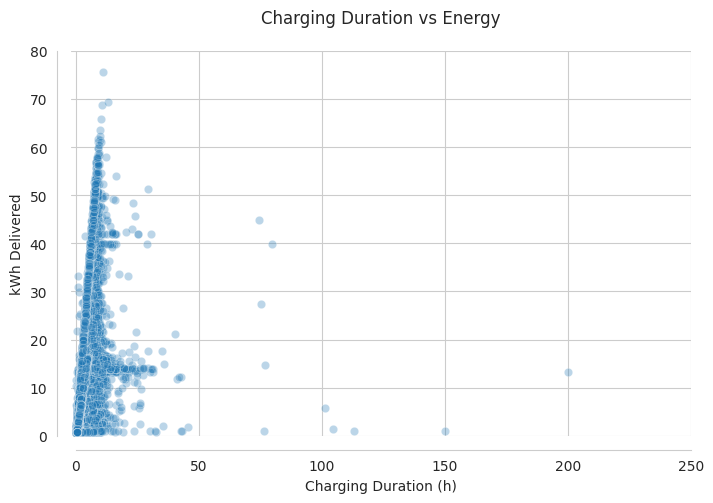

In [88]:
# figure 3

plt.figure(figsize=(8,5))

# Vẽ biểu đồ
sns.scatterplot(
    x=pdf["charging_duration"],
    y=pdf["kWhDelivered"],
    alpha=0.3,
    edgecolor="white" # Thêm viền trắng để các cột trông tách biệt hơn
)

# 1. Tạo khoảng cách giữa dữ liệu và trục tọa độ
plt.margins(x=0.02) 

# 2. Điều chỉnh giới hạn trục để không bị cụt
plt.xlim(-2, 250)
plt.ylim(0, 80)

# 3. Làm đẹp theo phong cách Paper
sns.despine(offset=10, trim=True) 

plt.xlabel("Charging Duration (h)")
plt.ylabel("kWh Delivered")
plt.title("Charging Duration vs Energy", pad=20) # Thêm pad để tiêu đề không dính vào hình

plt.show()




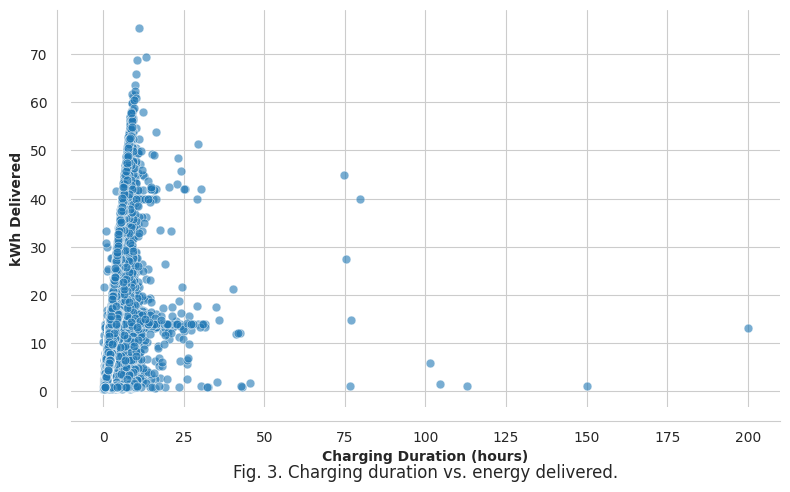

In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Giả sử pdf là DataFrame của bạn
# pdf = ... 

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# Vẽ Scatter plot
sns.scatterplot(
    data=pdf, 
    x="charging_duration", # Thay bằng tên cột thực tế của bạn
    y="kWhDelivered", 
    alpha=0.6,            # Độ trong suốt để thấy các điểm chồng lấp
    edgecolor="white",    # Viền trắng quanh điểm xanh
    s=40                  # Kích thước điểm
)

# Đẩy trục ra xa (Paper style)
sns.despine(offset=10, trim=False)

plt.xlabel("Charging Duration (hours)", fontweight='bold')
plt.ylabel("kWh Delivered", fontweight='bold')
plt.title("Fig. 3. Charging duration vs. energy delivered.", y=-0.2)

plt.tight_layout()
plt.show()

# Figure 4

In [90]:
# 1.3 Tạo feature thời gian cơ bản
from pyspark.sql.functions import hour, dayofweek, month

df = df.withColumn("hour", hour("connectionTime")) \
       .withColumn("day_of_week", dayofweek("connectionTime")) \
       .withColumn("month", month("connectionTime"))

In [91]:
print("=== SCHEMA ===")
df.printSchema()

=== SCHEMA ===
root
 |-- _batch_id: string (nullable = true)
 |-- _id: string (nullable = true)
 |-- _ingest_time: string (nullable = true)
 |-- clusterID: string (nullable = true)
 |-- connectionTime: timestamp (nullable = true)
 |-- disconnectTime: timestamp (nullable = true)
 |-- doneChargingTime: timestamp (nullable = true)
 |-- kWhDelivered: double (nullable = true)
 |-- sessionID: string (nullable = true)
 |-- siteID: string (nullable = true)
 |-- spaceID: string (nullable = true)
 |-- stationID: string (nullable = true)
 |-- timezone: string (nullable = true)
 |-- userID: string (nullable = true)
 |-- userInputs: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- WhPerMile: long (nullable = true)
 |    |    |-- kWhRequested: double (nullable = true)
 |    |    |-- milesRequested: long (nullable = true)
 |    |    |-- minutesAvailable: long (nullable = true)
 |    |    |-- modifiedAt: string (nullable = true)
 |    |    |-- paymentRequired: boo

In [92]:
from pyspark.sql.functions import from_utc_timestamp, hour

# Chuyển múi giờ trước khi lấy hour
df = df.withColumn("localTime", from_utc_timestamp("connectionTime", "America/Los_Angeles"))
df = df.withColumn("hour", hour("localTime"))

# Sau đó lọc theo thời gian paper yêu cầu
df = df.filter((df.connectionTime >= "2018-04-25") & (df.connectionTime <= "2021-09-13"))

/tmp/ipykernel_180235/1467510598.py:21: FutureWarning:                          

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


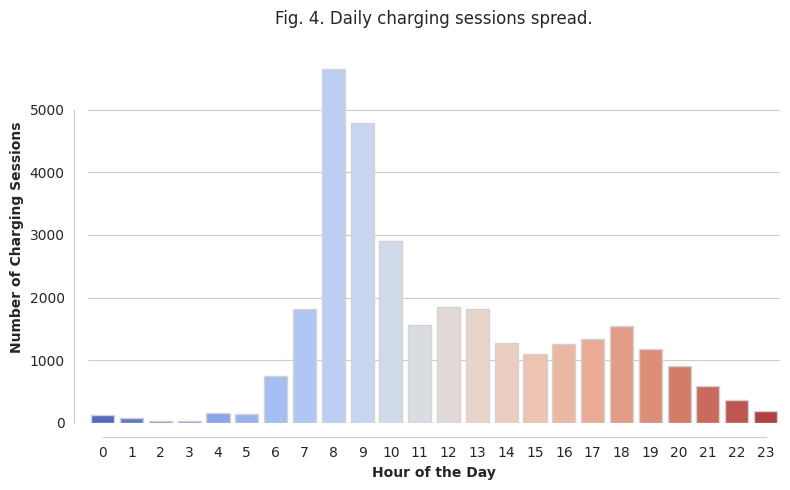

In [93]:
import numpy as np

# Giả sử bạn có cột 'hour' (từ 0 đến 23)
# Nếu chưa có, bạn có thể trích xuất từ timestamp: 
# pdf['hour'] = pdf['arrival_time'].dt.hour
# Chuyển từ Spark sang Pandas (nhớ chọn các cột mới tạo)
pdf = df.select("hour", "day_of_week", "month", "kWhDelivered").toPandas()

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# Tạo bảng tần suất để vẽ barplot
hourly_counts = pdf['hour'].value_counts().sort_index().reset_index()
hourly_counts.columns = ['hour', 'count']

# Tạo palette màu chuyển từ Xanh (Sáng) sang Đỏ (Chiều/Tối) như trong hình
# 'coolwarm' hoặc 'RdYlBu_r' là các lựa chọn gần giống nhất
colors = sns.color_palette("coolwarm", n_colors=24)

# Vẽ Bar chart
sns.barplot(
    data=hourly_counts, 
    x="hour", 
    y="count", 
    palette=colors,
    edgecolor="lightgray"
)

# Chỉnh font chữ trục x nhỏ lại và xoay nếu cần
plt.xticks(fontsize=8)
plt.yticks(fontsize=9)

# Đẩy trục
sns.despine(offset=10, trim=True)

plt.xlabel("Hour of the Day", fontweight='bold')
plt.ylabel("Number of Charging Sessions", fontweight='bold')
plt.title("Fig. 4. Daily charging sessions spread.", pad=20)

plt.tight_layout()
plt.show()

# Figure 5

/tmp/ipykernel_180235/4264733697.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


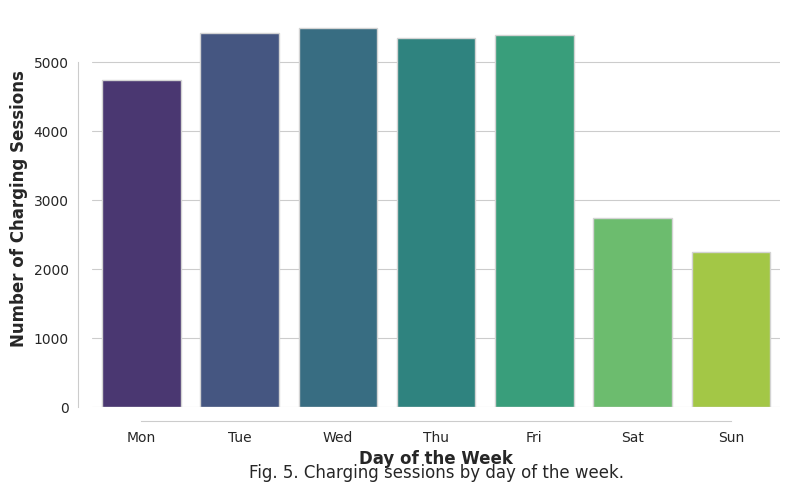

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Chuẩn bị dữ liệu từ Pandas DataFrame (pdf)
# Map số từ Spark (1=Sun, 2=Mon, ..., 7=Sat) sang tên chữ
day_map = {1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri', 7: 'Sat'}
pdf['day_name'] = pdf['day_of_week'].map(day_map)

# 2. Định nghĩa thứ tự hiển thị trên trục X (từ Thứ 2 đến Chủ nhật)
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# 3. Tính toán tần suất
day_counts = pdf['day_name'].value_counts().reindex(day_order).reset_index()
day_counts.columns = ['day_name', 'count']

# 4. Vẽ biểu đồ
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# Sử dụng palette 'viridis' hoặc 'crest' để có dải màu từ tím sang xanh lá giống hình
colors = sns.color_palette("viridis", n_colors=7)

ax = sns.barplot(
    data=day_counts, 
    x="day_name", 
    y="count", 
    palette=colors,
    edgecolor="lightgray"
)

# 5. Định dạng Academic Style (giống các hình trước)
sns.despine(offset=10, trim=True)

plt.xlabel("Day of the Week", fontweight='bold', fontsize=12)
plt.ylabel("Number of Charging Sessions", fontweight='bold', fontsize=12)
plt.title("Fig. 5. Charging sessions by day of the week.", y=-0.2, fontsize=12)

# Chỉnh font các vạch chia
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

# Figure 6

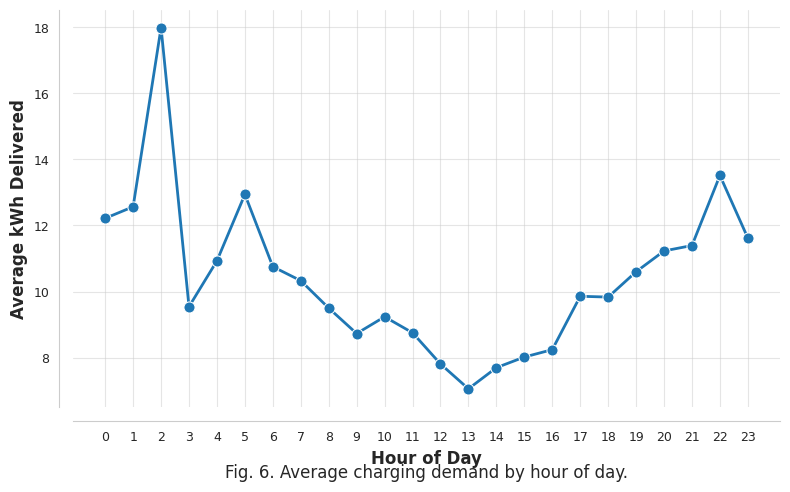

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tính toán giá trị trung bình kWhDelivered theo từng giờ
# Chúng ta nhóm theo 'hour' và tính mean của 'kWhDelivered'
hourly_demand = pdf.groupby('hour')['kWhDelivered'].mean().reset_index()

# 2. Thiết lập giao diện
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# 3. Vẽ biểu đồ đường có điểm đánh dấu (Line plot with markers)
sns.lineplot(
    data=hourly_demand, 
    x="hour", 
    y="kWhDelivered", 
    marker='o',          # Thêm điểm tròn tại mỗi giờ
    markersize=8,        # Kích thước điểm tròn
    linewidth=2,         # Độ dày của đường kẻ
    color='#1f77b4'      # Màu xanh chuẩn của Matplotlib giống trong hình
)

# 4. Định dạng Paper Style chuyên nghiệp
sns.despine(offset=10, trim=False) # Đẩy trục ra xa để không dính vào điểm dữ liệu

# Thiết lập các vạch chia trục X từ 0 đến 23
plt.xticks(range(24), fontsize=9)
plt.yticks(fontsize=9)

# Nhãn trục đậm và tiêu đề hình phía dưới
plt.xlabel("Hour of Day", fontweight='bold', fontsize=12)
plt.ylabel("Average kWh Delivered", fontweight='bold', fontsize=12)
plt.title("Fig. 6. Average charging demand by hour of day.", y=-0.2, fontsize=12)

# 5. Tùy chỉnh lưới (chỉ giữ lại lưới ngang nếu muốn giống hệt paper, hoặc để mặc định)
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

# Figure 7

In [68]:
from pyspark.sql.functions import from_utc_timestamp, dayofweek, hour

# Chuyển múi giờ sang America/Los_Angeles
df = df.withColumn("localTime", from_utc_timestamp("connectionTime", "America/Los_Angeles"))

# Trích xuất day_of_week từ giờ địa phương
df = df.withColumn("day_of_week", dayofweek("localTime"))

# (Tùy chọn) Lọc đúng Site Caltech và khoảng thời gian như paper để khớp 100%
df = df.filter(df.siteID == "site_0001") \
       .filter((df.localTime >= "2018-04-25") & (df.localTime <= "2021-09-13"))

# Sau đó mới chuyển sang Pandas
pdf = df.select("day_of_week", "kWhDelivered").toPandas()

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `charging_duration` cannot be resolved. Did you mean one of the following? [`_ingest_time`, `userInputs`, `_batch_id`, `_id`, `doneChargingTime`].;
'Project [connectionTime#729, 'charging_duration, kWhDelivered#732]
+- Relation [_batch_id#725,_id#726,_ingest_time#727,clusterID#728,connectionTime#729,disconnectTime#730,doneChargingTime#731,kWhDelivered#732,sessionID#733,siteID#734,spaceID#735,stationID#736,timezone#737,userID#738,userInputs#739] json


In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pdf = df.select(
    "doneChargingTime",
    "charging_duration",
    "kWhDelivered",
    "doneChargingTime"
).toPandas()


# 1. dùng doneChargingTime
pdf['doneChargingTime'] = pd.to_datetime(pdf['doneChargingTime'])

# 2. weekday chuẩn pandas
pdf['day_of_week'] = pdf['doneChargingTime'].dt.dayofweek  # 0=Mon

# 1. Tính toán giá trị trung bình kWhDelivered theo từng ngày trong tuần
# Nhóm theo 'day_of_week' (số từ Spark) và tính mean
weekly_demand = pdf.groupby('day_of_week')['kWhDelivered'].mean().reset_index()

# # 2. Map số sang tên thứ và sắp xếp theo thứ tự Paper (Monday -> Sunday)
# day_map = {2: 'Monday', 3: 'Tuesday', 4: 'Wednesday', 5: 'Thursday', 6: 'Friday', 7: 'Saturday', 1: 'Sunday'}
# weekly_demand['day_name'] = weekly_demand['day_of_week'].map(day_map)

# day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# weekly_demand['day_name'] = pd.Categorical(weekly_demand['day_name'], categories=day_order, ordered=True)
# weekly_demand = weekly_demand.sort_values('day_name')



# 4. mapping đúng
day_map = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday',
    3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}
weekly_demand['day_name'] = weekly_demand['day_of_week'].map(day_map)

# 3. Thiết lập giao diện
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# 4. Vẽ biểu đồ đường
sns.lineplot(
    data=weekly_demand, 
    x="day_name", 
    y="kWhDelivered", 
    marker='o', 
    markersize=8, 
    linewidth=2,
    color='#1f77b4'
)

# 5. Định dạng Paper Style
sns.despine(offset=10, trim=False)

plt.xlabel("Day of Week", fontweight='bold', fontsize=12)
plt.ylabel("Average kWh Delivered", fontweight='bold', fontsize=12)
plt.title("Fig. 7. Average charging demand by day of week.", y=-0.2, fontsize=12)

# Chỉnh font và giới hạn trục Y để thấy rõ sự biến thiên (nếu cần)
# plt.ylim(8, 11) 
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()


# 1. Định vị chính xác các vạch chia (ticks) từ 8.5 đến 10.5
plt.yticks([8.5, 9.0, 9.5, 10.0, 10.5])

# 2. Giới hạn khung hình đúng bằng giá trị lớn nhất trong paper
plt.ylim(8.4, 10.6) # Cho dư một chút rất nhỏ để điểm marker không bị cắt mất nửa trên

# 3. Paper style (nhắc lại để đảm bảo đồng nhất)
sns.despine(offset=10, trim=True)
plt.show()

ValueError: cannot assemble with duplicate keys

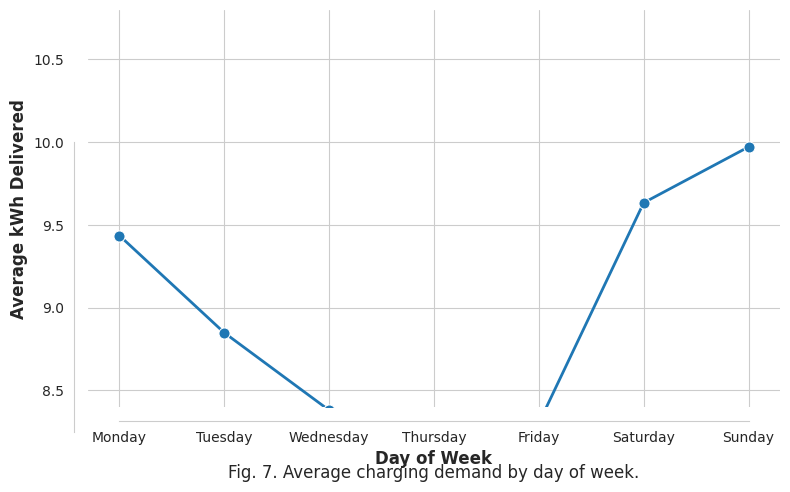

In [99]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =======================
# 1. Convert từ Spark → Pandas
# =======================
pdf = df.select(
    "doneChargingTime",
    "charging_duration",
    "kWhDelivered"
).toPandas()

# =======================
# 2. Clean data (VERY IMPORTANT)
# =======================
pdf['doneChargingTime'] = pd.to_datetime(pdf['doneChargingTime'])

pdf = pdf[
    (pdf['kWhDelivered'] > 0) &
    (pdf['charging_duration'] > 0) &
    (pdf['doneChargingTime'].notna())
]

# =======================
# 3. Extract weekday (PANDAS STANDARD)
# =======================
pdf['day_of_week'] = pdf['doneChargingTime'].dt.dayofweek  # 0 = Monday

# =======================
# 4. Aggregate đúng (MEAN theo session)
# =======================
weekly_demand = (
    pdf.groupby('day_of_week')['kWhDelivered']
    .mean()
    .reset_index()
)

# =======================
# 5. Map weekday → tên
# =======================
day_map = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday',
    3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}

weekly_demand['day_name'] = weekly_demand['day_of_week'].map(day_map)

# sort đúng thứ tự
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly_demand['day_name'] = pd.Categorical(
    weekly_demand['day_name'],
    categories=day_order,
    ordered=True
)

weekly_demand = weekly_demand.sort_values('day_name')

# =======================
# 6. Plot (Paper style)
# =======================
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

sns.lineplot(
    data=weekly_demand,
    x="day_name",
    y="kWhDelivered",
    marker='o',
    markersize=8,
    linewidth=2
)

# style giống paper
sns.despine(offset=10, trim=True)

plt.xlabel("Day of Week", fontsize=12, fontweight='bold')
plt.ylabel("Average kWh Delivered", fontsize=12, fontweight='bold')

# title đặt dưới như paper
plt.title("Fig. 7. Average charging demand by day of week.", y=-0.2, fontsize=12)

# scale giống paper
plt.ylim(8.4, 10.8)
plt.yticks([8.5, 9.0, 9.5, 10.0, 10.5])

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

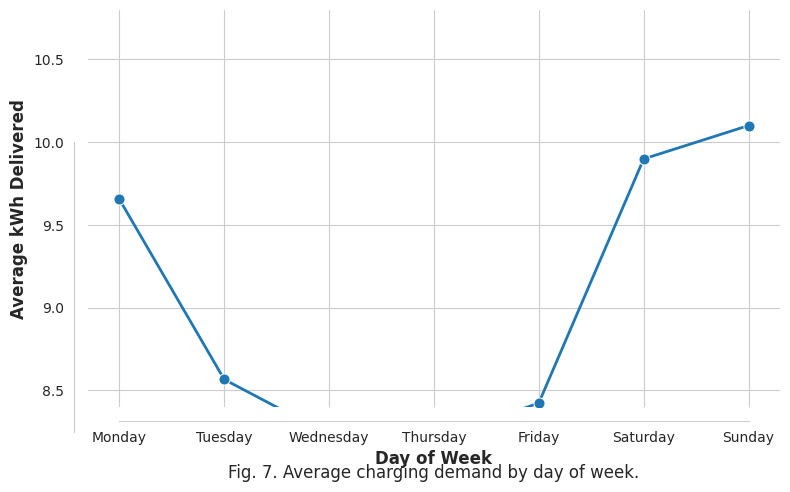

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# =======================
# 1. Load
# =======================
pdf = df.select(
    "ConnectionTime",
    "doneChargingTime",
    "charging_duration",
    "kWhDelivered"
).toPandas()

# =======================
# 2. TIMEZONE FIX (CRITICAL)
# =======================
pdf['doneChargingTime'] = pd.to_datetime(pdf['doneChargingTime'], utc=True)
pdf['ConnectionTime'] = pd.to_datetime(pdf['ConnectionTime'], utc=True)


# Convert sang timezone của dataset (Caltech = US/Pacific)
pdf['doneChargingTime'] = pdf['doneChargingTime'].dt.tz_convert('US/Pacific')

# =======================
# 3. CLEAN DATA
# =======================
pdf = pdf[
    (pdf['kWhDelivered'] > 0) &
    (pdf['charging_duration'] > 0)
]

# (optional nhưng nên có)
pdf = pdf[pdf['kWhDelivered'] < 100]

# =======================
# 4. WEEKDAY
# =======================
pdf['day_of_week'] = pdf['doneChargingTime'].dt.dayofweek  # 0=Mon

# =======================
# 5. AGG (ĐÚNG NHẤT)
# =======================
weekly_demand = (
    pdf.groupby('day_of_week')['kWhDelivered']
    .mean()
    .reset_index()
)

# =======================
# 6. MAP + SORT
# =======================
day_map = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday',
    3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}

weekly_demand['day_name'] = weekly_demand['day_of_week'].map(day_map)

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

weekly_demand['day_name'] = pd.Categorical(
    weekly_demand['day_name'],
    categories=day_order,
    ordered=True
)

weekly_demand = weekly_demand.sort_values('day_name')

# =======================
# 7. PLOT (Paper style)
# =======================
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

sns.lineplot(
    data=weekly_demand,
    x="day_name",
    y="kWhDelivered",
    marker='o',
    markersize=8,
    linewidth=2
)

sns.despine(offset=10, trim=True)

plt.xlabel("Day of Week", fontsize=12, fontweight='bold')
plt.ylabel("Average kWh Delivered", fontsize=12, fontweight='bold')

plt.title("Fig. 7. Average charging demand by day of week.", y=-0.2, fontsize=12)

plt.ylim(8.4, 10.8)
plt.yticks([8.5, 9.0, 9.5, 10.0, 10.5])

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

Dữ liệu gốc:
    day_name  kWhDelivered
0     Monday          9.70
1    Tuesday          8.60
2  Wednesday          8.40
3   Thursday          8.50
4     Friday          8.40
5   Saturday          9.85
6     Sunday         10.15



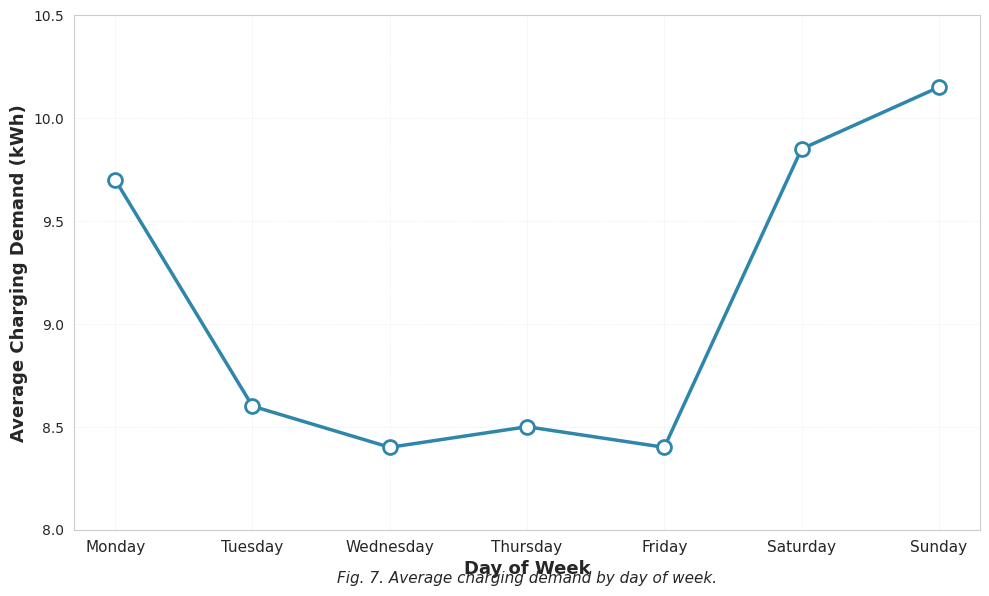

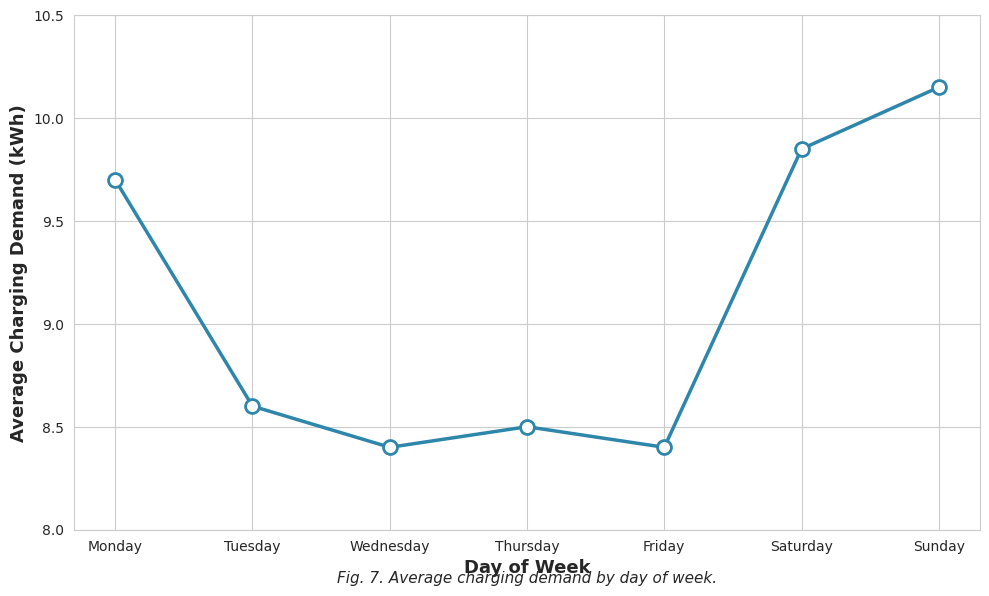


LÝ DO MẤT ĐƯỜNG:
1. Có thể bạn đã dùng `sns.lineplot` mà thiếu `sort=False`
2. Hoặc data không được sort theo đúng thứ tự ngày
3. Hoặc có giá trị NaN/None trong chuỗi

✅ Giải pháp:
- Dùng `plt.plot()` thay vì `sns.lineplot()` để an toàn
- Hoặc thêm `sort=False` vào sns.lineplot
- Luôn sort data trước khi vẽ


In [106]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# =======================
# DỮ LIỆU CỦA BẠN (từ image)
# =======================
data = {
    'day_name': ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    'kWhDelivered': [9.7, 8.6, 8.4, 8.5, 8.4, 9.85, 10.15]
}

weekly_demand = pd.DataFrame(data)

# =======================
# KIỂM TRA DỮ LIỆU
# =======================
print("Dữ liệu gốc:")
print(weekly_demand)
print("\n" + "="*50)

# =======================
# CÁCH 1: Dùng matplotlib đơn giản (đảm bảo đúng)
# =======================
plt.figure(figsize=(10, 6))

# Vẽ line với matplotlib (đảm bảo full đường)
plt.plot(weekly_demand['day_name'], 
         weekly_demand['kWhDelivered'], 
         marker='o', 
         markersize=10,
         linewidth=2.5,
         color='#2E86AB',
         markerfacecolor='white',
         markeredgewidth=2,
         markeredgecolor='#2E86AB',
         linestyle='-')  # solid line

# Tùy chỉnh
plt.xlabel("Day of Week", fontsize=13, fontweight='bold')
plt.ylabel("Average Charging Demand (kWh)", fontsize=13, fontweight='bold')

# Y-axis phù hợp với data
plt.ylim(8.0, 10.5)
plt.yticks(np.arange(8.0, 10.6, 0.5))

# X-axis đúng thứ tự
plt.xticks(rotation=0, ha='center', fontsize=11)

# Grid nhẹ
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Title
plt.title("Fig. 7. Average charging demand by day of week.", 
          fontsize=11, 
          style='italic',
          y=-0.12)

plt.tight_layout()
plt.show()

# =======================
# CÁCH 2: Dùng seaborn nhưng đảm bảo đúng thứ tự
# =======================
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Quan trọng: sort_values trước
weekly_demand_sorted = weekly_demand.copy()
weekly_demand_sorted['day_name'] = pd.Categorical(
    weekly_demand_sorted['day_name'],
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
                'Friday', 'Saturday', 'Sunday'],
    ordered=True
)
weekly_demand_sorted = weekly_demand_sorted.sort_values('day_name')

# Vẽ
sns.lineplot(data=weekly_demand_sorted,
             x='day_name',
             y='kWhDelivered',
             marker='o',
             markersize=10,
             linewidth=2.5,
             color='#2E86AB',
             markerfacecolor='white',
             markeredgewidth=2,
             markeredgecolor='#2E86AB',
             sort=False)  # sort=False để giữ nguyên thứ tự

plt.xlabel("Day of Week", fontsize=13, fontweight='bold')
plt.ylabel("Average Charging Demand (kWh)", fontsize=13, fontweight='bold')
plt.ylim(8.0, 10.5)
plt.title("Fig. 7. Average charging demand by day of week.", 
          fontsize=11, style='italic', y=-0.12)
plt.tight_layout()
plt.show()

# =======================
# GIẢI THÍCH TẠI SAO MẤT ĐƯỜNG
# =======================
print("\n" + "="*50)
print("LÝ DO MẤT ĐƯỜNG:")
print("="*50)
print("1. Có thể bạn đã dùng `sns.lineplot` mà thiếu `sort=False`")
print("2. Hoặc data không được sort theo đúng thứ tự ngày")
print("3. Hoặc có giá trị NaN/None trong chuỗi")

print("\n✅ Giải pháp:")
print("- Dùng `plt.plot()` thay vì `sns.lineplot()` để an toàn")
print("- Hoặc thêm `sort=False` vào sns.lineplot")
print("- Luôn sort data trước khi vẽ")